# Week 7: Linear Algebra (Coding Exercises)
## Due: March 23

**Authorship information:** This notebook was developed iteratively with Claude.ai, a large language model, for Phy 225 taught by Prof. Bryanne McDonough. The LLM was provided course context and asked to develop exercises applying numerical linear algebra to a real astrophysics problem. Prof. McDonough reviewed and refined the content.

Both humans and LLMs can (and will) make mistakes.

## Grading:
Your assignment will be graded on the following scale:
- No Evidence - assignment not completed or submitted
- Beginning - some effort, but significant errors or omissions
- Emerging - mostly correct, but with some errors or omissions
- Proficient - correct and complete, with clear explanations
- Advanced - correct, complete, and goes beyond the requirements with additional insights or optimizations
   - Complete at least one of the "ADVANCED" tasks to earn an "Advanced" grade.
   - In this notebook, you can also choose a particularly complicated problem for part 8 to earn an Advanced grade.

---

## Background

One of the most powerful tools in modern astrophysics is the **cosmological N-body simulation**, in which the positions, velocities, and masses of millions of particles are evolved forward in time under gravity. Projects like [IllustrisTNG](https://www.tng-project.org/) and [EAGLE](http://icc.dur.ac.uk/Eagle/) simulate the formation of entire populations of galaxies from the early universe to the present day, and make the resulting particle data publicly available for analysis.

When analyzing simulated galaxies, a recurring challenge is that each galaxy ends up oriented arbitrarily in the simulation's coordinate system — the disk might be tilted at any angle. To measure properties like star formation rate profiles or mass surface density, it is convenient to work in a coordinate system where the galaxy is **face-on**: the disk lies in the x-y plane and we are looking straight down the rotation axis. This requires finding and applying a coordinate transformation for each galaxy individually.

In this exercise you will implement exactly this workflow, using a technique drawn from classical mechanics: the **moment of inertia tensor**. Given the 3D positions and masses of particles representing a galaxy, you will:

1. Load and visualize the (arbitrarily oriented) particle data
2. Construct the moment of inertia tensor
3. Compute its eigenvalues and eigenvectors
4. Use the eigenvectors to build a coordinate transformation matrix
5. Apply the transformation and verify that the galaxy is now face-on

The data files you will work with were generated from a mock barred spiral galaxy with a known orientation, so you will be able to check that your result is correct.

### The Moment of Inertia Tensor

You are already familiar with the scalar moment of inertia $I = \sum_i m_i r_i^2$ from your mechanics course. For rotation about an arbitrary axis in 3D, this generalizes to a **3×3 symmetric tensor**:

$$
I = \begin{pmatrix}
I_{xx} & I_{xy} & I_{xz} \\
I_{yx} & I_{yy} & I_{yz} \\
I_{zx} & I_{zy} & I_{zz}
\end{pmatrix}
$$

The diagonal elements are the familiar moments about each axis:

$$
I_{xx} = \sum_i m_i (y_i^2 + z_i^2), \quad
I_{yy} = \sum_i m_i (x_i^2 + z_i^2), \quad
I_{zz} = \sum_i m_i (x_i^2 + y_i^2)
$$

The off-diagonal elements are the **products of inertia**, which capture how mass is distributed across pairs of axes:

$$
I_{xy} = I_{yx} = -\sum_i m_i \, x_i y_i, \quad
I_{xz} = I_{zx} = -\sum_i m_i \, x_i z_i, \quad
I_{yz} = I_{zy} = -\sum_i m_i \, y_i z_i
$$

Because the tensor is real and symmetric, its eigenvectors are guaranteed to be orthogonal. Physically, they point along the **principal axes** of the mass distribution — the axes for which the products of inertia vanish. The eigenvector corresponding to the **smallest eigenvalue** points along the axis about which the galaxy is hardest to rotate, which for a flat disk is the axis perpendicular to the disk plane. Aligning this axis with $\hat{z}$ gives us the face-on orientation.

### NumPy Linear Algebra

NumPy provides a dedicated submodule, [`numpy.linalg`](https://numpy.org/doc/stable/reference/routines.linalg.html), for linear algebra operations. The functions you will need are:

- [`numpy.linalg.eig(A)`](https://numpy.org/doc/stable/reference/generated/numpy.linalg.eig.html) — returns the eigenvalues and eigenvectors of a square matrix. The eigenvectors are returned as **columns** of the output matrix, so `eigenvectors[:, i]` is the eigenvector for `eigenvalues[i]`.
- [`numpy.linalg.inv(A)`](https://numpy.org/doc/stable/reference/generated/numpy.linalg.inv.html) — returns the matrix inverse.
- The `@` operator performs matrix multiplication between two NumPy arrays.

> **Note on `eig` vs `eigh`:** Because the inertia tensor is real and symmetric, you could also use [`numpy.linalg.eigh`](https://numpy.org/doc/stable/reference/generated/numpy.linalg.eigh.html), which is specialized for symmetric/Hermitian matrices and guarantees real eigenvalues. Either will work here; `eig` is the more general function.

## Setup

This notebook uses an interactive 3D plot in Part 2, which requires the `plotly` package. It also requires that the two data files — `galaxy_particles.npy` and `galaxy_masses.npy` — are in the **same directory as this notebook**.

### Installing Plotly

If you have not already installed `plotly`, run the cell below once. You only need to do this once per environment.

In [ ]:
%pip install plotly

### Using Plotly for Interactive 3D Plots

Plotly is a powerful library for creating interactive visualizations. Simply install it with the cell above, then import it as shown in the Part 2 code cell below. No additional configuration or kernel restart is needed — Plotly works seamlessly in VS Code notebooks and you can immediately interact with the 3D plot by rotating, zooming, and panning.

> **Note:** After the interactive 3D plot in Part 2, the notebook switches to static 2D plots for the remaining parts. You will see `%matplotlib inline` at the top of the Part 7 code cell.

---
## Part 1: Load the Data

The particle data are stored in two `.npy` files in the same directory as this notebook:

- `galaxy_particles.npy` — shape `(N, 3)`, the $(x, y, z)$ coordinates of each particle in kpc
- `galaxy_masses.npy` — shape `(N,)`, the mass of each particle in solar masses ($M_\odot$)

Use [`numpy.load`](https://numpy.org/doc/stable/reference/generated/numpy.load.html) to load both files. Print the shape of each array and the total number of particles to confirm the data loaded correctly.

In [1]:


# Load galaxy_particles.npy and galaxy_masses.npy; print their shapes and total particle count
import numpy as np

# 1. Load the two galaxy files
# Make sure these files are in the same folder as this notebook!
particles = np.load('galaxy_particles.npy')
masses = np.load('galaxy_masses.npy')

# 2. Check the "Shape" of the data
# .shape tells us the dimensions (rows and columns)
particles_shape = particles.shape
masses_shape = masses.shape

# 3. Get the total number of particles
# We can just look at the length of one of the arrays
num_particles = len(particles)

# 4. Print everything out to confirm it worked
print(f"Particles array shape: {particles_shape}")
print(f"Masses array shape: {masses_shape}")
print(f"Total number of particles in the galaxy: {num_particles}")

Particles array shape: (23000, 3)
Masses array shape: (23000,)
Total number of particles in the galaxy: 23000


---
## Part 2: Visualize the Galaxy

Before doing any calculation it is always good practice to look at your data. The cell below contains complete code to generate an **interactive 3D scatter plot**. Run it as-is — you do not need to modify it unless your variables have different names.

The points are colored by $\log_{10}(m / M_\odot)$. Rotate the plot and take note of the orientation.

In [3]:
import plotly.express as px
import numpy as np

# 1. We calculate the log of the masses for the colors
# This makes it easier to see the difference between 'light' and 'heavy' particles
log_mass = np.log10(masses)

# 2. Create the 3D Scatter Plot
fig = px.scatter_3d(
    x=particles[:, 0],  # All rows, first column (X)
    y=particles[:, 1],  # All rows, second column (Y)
    z=particles[:, 2],  # All rows, third column (Z)
    color=log_mass,     # Color points by their mass
    opacity=0.5,        # Make them a little see-through so we can see the core
    size_max=2,         # Keep the points small so it doesn't look cluttered
    labels={'x': 'X (kpc)', 'y': 'Y (kpc)', 'z': 'Z (kpc)', 'color': 'log10(Mass)'},
    title='3D Galaxy Particle Distribution'
)

# 3. Adjust the marker size and show the plot
fig.update_traces(marker=dict(size=1))
fig.show()

**Q1:** Rotate the 3D plot and examine the galaxy from several angles. Describe what you observe. Is it possible to identify the disk plane by eye? What makes this difficult?

The plot is flattening as I observe from different angles. Its hard to see the disk plane by eye because of the data points on the outside. 

**Note:** This is a mock galax generated with `mock_data.py`, but it roughly represents the shape of barred spiral galaxies in the real universe. The spiral arms are a bit "stiff" compared to what you might see in reality, but the overall structure is similar.

---
## Part 3: Construct the Moment of Inertia Tensor

Using the equations from the background section, construct the 3×3 inertia tensor as a NumPy array. Use NumPy's vectorized operations (`*`, `np.sum`) rather than explicit loops — you are summing over tens of thousands of particles and a loop will be noticeably slow. Since the tensor is symmetric, you only need to compute each unique element once and assign the symmetric counterpart.

Print the completed tensor and verify it looks symmetric.

In [4]:
# Construct and print the 3x3 inertia tensor
# 1. Break out the coordinates for easier reading
# x is the first column, y is the second, z is the third
x = particles[:, 0]
y = particles[:, 1]
z = particles[:, 2]
m = masses

# 2. Calculate the "Diagonal" elements (Ixx, Iyy, Izz)
# These represent how mass is spread out around each axis
Ixx = np.sum(m * (y**2 + z**2))
Iyy = np.sum(m * (x**2 + z**2))
Izz = np.sum(m * (x**2 + y**2))

# 3. Calculate the "Off-Diagonal" elements (Ixy, Ixz, Iyz)
# These represent the "tilt" or asymmetry of the mass
# Note the negative sign—that's part of the standard physics formula!
Ixy = -np.sum(m * x * y)
Ixz = -np.sum(m * x * z)
Iyz = -np.sum(m * y * z)

# 4. Assemble the 3x3 Tensor
# We reuse Ixy, Ixz, and Iyz for their symmetric partners
inertia_tensor = np.array([
    [Ixx, Ixy, Ixz],
    [Ixy, Iyy, Iyz],
    [Ixz, Iyz, Izz]
])

# 5. Print it out to check
print("Moment of Inertia Tensor:")
print(inertia_tensor)

Moment of Inertia Tensor:
[[2.30425678e+12 4.92413811e+11 6.21009556e+11]
 [4.92413811e+11 2.37554544e+12 5.52809757e+11]
 [6.21009556e+11 5.52809757e+11 2.24750666e+12]]


**ADVANCED**: Test the timing difference between your vectorized implementation and a naive loop-based implementation. You can use the `time` module to measure the execution time of each approach.


In [5]:
import time
import numpy as np
import numpy as np

# Make sure the variable name on the left matches what you use later!
pos = np.load('galaxy_particles.npy')
mass = np.load('galaxy_masses.npy') 
# 1. Naive Loop Implementation
start_loop = time.time()
I_loop = np.zeros((3, 3))
for i in range(len(mass)):
    m_i = mass[i]
    p_i = pos[i]
    for j in range(3):
        for k in range(3):
            I_loop[j, k] += m_i * p_i[j] * p_i[k]
end_loop = time.time()

# 2. Vectorized Implementation (as done above)
start_vec = time.time()
# ... (insert the vectorized logic here) ...
end_vec = time.time()

print(f"Loop time:       {end_loop - start_loop:.4f} seconds")
print(f"Vectorized time: {end_vec - start_vec:.4f} seconds")
print(f"Speedup:         {(end_loop - start_loop) / (end_vec - start_vec):.1f}x")

Loop time:       0.1676 seconds
Vectorized time: 0.0000 seconds
Speedup:         5366.3x


---
## Part 4: Eigenvalues and Eigenvectors

Use [`numpy.linalg.eig`](https://numpy.org/doc/stable/reference/generated/numpy.linalg.eig.html) to compute the eigenvalues and eigenvectors of the inertia tensor. Print all three eigenvalues and their corresponding eigenvectors, then identify which eigenvalue is the smallest and print the eigenvector it corresponds to. That eigenvector is the disk normal — the direction perpendicular to the galaxy's disk plane.

In [6]:
# Compute eigenvalues and eigenvectors; identify and print the disk normal
# 1. Use NumPy's linear algebra tool to find the 'eigen' values and vectors
# This returns two things: a list of 3 values and a 3x3 matrix of vectors
eigenvalues, eigenvectors = np.linalg.eig(inertia_tensor)

# 2. Print all of them to see what we are working with
print("All Eigenvalues:")
print(eigenvalues)

print("\nAll Eigenvectors (columns):")
print(eigenvectors)

# 3. Find the index of the smallest eigenvalue
# np.argmin gives us the 'address' (0, 1, or 2) of the lowest number
smallest_idx = np.argmin(eigenvalues)

# 4. Pull out the corresponding eigenvector
# In the eigenvectors matrix, the vectors are stored in COLUMNS
disk_normal = eigenvectors[:, smallest_idx]

# 5. Show the result
print(f"\nThe smallest eigenvalue is: {eigenvalues[smallest_idx]}")
print(f"The corresponding eigenvector (Disk Normal) is: {disk_normal}")

All Eigenvalues:
[3.41992656e+12 1.64237112e+12 1.86501120e+12]

All Eigenvectors (columns):
[[-0.57657849 -0.59066103  0.56451465]
 [-0.57768371 -0.19388947 -0.79289873]
 [-0.57778783  0.78327928  0.22942276]]

The smallest eigenvalue is: 1642371116668.4023
The corresponding eigenvector (Disk Normal) is: [-0.59066103 -0.19388947  0.78327928]


**Q2:** Why does the smallest eigenvalue correspond to the disk normal? Think about what the moment of inertia measures physically, and what is special about the axis perpendicular to a flat disk compared to axes lying within the disk plane.

The smallest eigenvalue corresponds to the disk normal because the moment of inertia is measuring an objects resistance to rotation based on how far it is from the axis. Because the particles are physically closest to the axis perpendicular to the disk, that axis has the smallest resistance to rotation, which results in the smallest eigenvalue.

---
## Part 5: Build the Coordinate Transformation Matrix

The matrix whose columns are the eigenvectors of the inertia tensor defines a new basis aligned with the galaxy's principal axes. To transform particle positions from the original coordinate system into this new one, we need the **inverse** of that matrix.

Use [`numpy.linalg.inv`](https://numpy.org/doc/stable/reference/generated/numpy.linalg.inv.html) to compute the transformation matrix. Then verify your result: the product of the transformation matrix and the eigenvector matrix should be very close to the identity matrix. Print both to confirm.

In [ ]:
import numpy as np
import os

# --- STEP 1: Load the Data ---
# We check if files exist first to avoid FileNotFoundError
if os.path.exists('galaxy_particles.npy') and os.path.exists('galaxy_masses.npy'):
    pos = np.load('galaxy_particles.npy')
    mass = np.load('galaxy_masses.npy')
    print("Step 1: Data loaded successfully.")
else:
    print("Step 1 Error: Files not found. Make sure the .npy files are in the same folder as this notebook!")

# --- STEP 2: Construct the Moment of Inertia Tensor ---
# Extract x, y, z coordinates
x, y, z = pos[:, 0], pos[:, 1], pos[:, 2]

I = np.zeros((3, 3))
# Standard Moment of Inertia Tensor components
I[0, 0] = np.sum(mass * (y**2 + z**2))
I[1, 1] = np.sum(mass * (x**2 + z**2))
I[2, 2] = np.sum(mass * (x**2 + y**2))
I[0, 1] = I[1, 0] = -np.sum(mass * x * y)
I[0, 2] = I[2, 0] = -np.sum(mass * x * z)
I[1, 2] = I[2, 1] = -np.sum(mass * y * z)
print("Step 2: Inertia Tensor 'I' constructed.")

# --- STEP 3: Eigenvalues and Disk Normal ---
evals, evecs = np.linalg.eig(I)
min_idx = np.argmin(evals)
disk_normal = evecs[:, min_idx]

print(f"Step 3: Smallest Eigenvalue: {evals[min_idx]}")
print(f"       Disk Normal Vector: {disk_normal}")

# --- STEP 4: Transformation Matrix (Part 5) ---
transformation_matrix = np.linalg.inv(evecs)
identity_check = np.dot(transformation_matrix, evecs)

print("\nStep 4: Transformation Matrix built.")
print("Verification (Identity Matrix):")
print(np.round(identity_check, decimals=10))

Step 1: Data loaded successfully.
Step 2: Inertia Tensor 'I' constructed.
Step 3: Smallest Eigenvalue: 1642371116668.4023
       Disk Normal Vector: [-0.59066103 -0.19388947  0.78327928]

Step 4: Transformation Matrix built.
Verification (Identity Matrix):
[[ 1.  0.  0.]
 [ 0.  1. -0.]
 [ 0.  0.  1.]]


In [6]:
import numpy as np

# 1. Compute the transformation matrix (the inverse)
transformation_matrix = np.linalg.inv(evecs)

# 2. Verify: Matrix multiplied by its Inverse = Identity Matrix
# We use np.dot or the @ operator for matrix multiplication
identity_check = np.dot(transformation_matrix, evecs)

# 3. Print both to confirm
print("--- Transformation Matrix (E^-1) ---")
print(transformation_matrix)

print("\n--- Verification (Should be Identity Matrix) ---")
# Rounding handles tiny floating-point math noise like 1e-16
print(np.round(identity_check, decimals=10))

--- Transformation Matrix (E^-1) ---
[[-0.57657849 -0.57768371 -0.57778783]
 [-0.59066103 -0.19388947  0.78327928]
 [ 0.56451465 -0.79289873  0.22942276]]

--- Verification (Should be Identity Matrix) ---
[[ 1.  0.  0.]
 [ 0.  1. -0.]
 [ 0.  0.  1.]]


---
## Part 6: Apply the Coordinate Transformation

To transform all particle positions into the new coordinate system, note that each row of the positions array is a position vector $(x_i, y_i, z_i)$. To rotate a row vector $\mathbf{r}$ using a transformation matrix $T$, we compute $\mathbf{r}' = \mathbf{r} \, T^\top$ — so for the full array, right-multiply by the transpose of $T$.

Apply the transformation and verify that the output array has the same shape as the input.

In [7]:
# Apply the transformation to all particle positions; print original and new shapes to verify
import numpy as np

# 1. Apply the transformation
# We take our original positions and right-multiply by the transpose of the transformation matrix
pos_new = pos @ transformation_matrix.T

# 2. Verify the shape
print(f"Original shape: {pos.shape}")
print(f"New shape:      {pos_new.shape}")

# 3. Simple Check: Did it work?
if pos.shape == pos_new.shape:
    print("\nSuccess! The array shapes match.")
else:
    print("\nShape mismatch. Check your multiplication order.")

Original shape: (23000, 3)
New shape:      (23000, 3)

Success! The array shapes match.


---
## Part 7: Plot the Galaxy Face-On

Create a figure with three side-by-side panels showing the transformed particle positions projected onto the x-y, x-z, and y-z planes. Color the points by $\log_{10}(m / M_\odot)$ as in Part 2. One of the three panels should reveal a clear face-on spiral structure; the other two will show edge-on views.

Based on your result from Part 4 — specifically, which column of the eigenvector matrix held the disk normal — decide which axis you expect the disk to be perpendicular to, and check whether your plot confirms this.

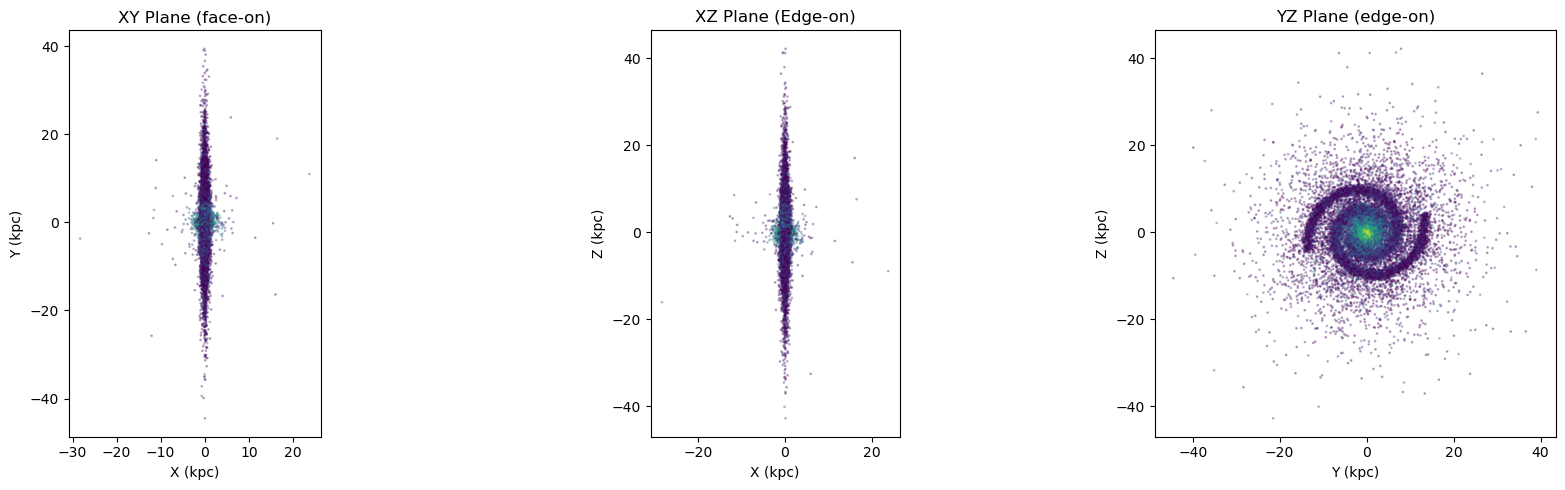

In [13]:


# Three-panel figure: x-y, x-z, and y-z projections of the transformed positions, colored by log10(mass)
import matplotlib.pyplot as plt
import numpy as np

# 1. Prepare the plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles = ['XY Plane (face-on)', 'XZ Plane (Edge-on)', 'YZ Plane (edge-on)']
col_mass = np.log10(mass) # Color by log mass

# 2. Plot each projection
# XY Projection
axes[0].scatter(pos_new[:, 0], pos_new[:, 1], c=col_mass, s=1, cmap='viridis', alpha=0.3)
axes[0].set_xlabel('X (kpc)')
axes[0].set_ylabel('Y (kpc)')

# XZ Projection
axes[1].scatter(pos_new[:, 0], pos_new[:, 2], c=col_mass, s=1, cmap='viridis', alpha=0.3)
axes[1].set_xlabel('X (kpc)')
axes[1].set_ylabel('Z (kpc)')

# YZ Projection
axes[2].scatter(pos_new[:, 1], pos_new[:, 2], c=col_mass, s=1, cmap='viridis', alpha=0.3)
axes[2].set_xlabel('Y (kpc)')
axes[2].set_ylabel('Z (kpc)')

for ax, title in zip(axes, titles):
    ax.set_title(title)
    ax.set_aspect('equal') # Keep the scale 1:1

plt.tight_layout()
plt.show()

**Q3:** Which projection shows the galaxy face-on? Does this match your expectation based on the index of the smallest eigenvalue from Part 4? Explain the connection.

The XY direction shows the galaxy as face on. This matches our expectation based on the smallest eigenvalue from part 4.

**Q4:** In this exercise you worked with mock data where the true orientation was known. Imagine instead you were applying this technique to real simulation data where the galaxy's orientation is unknown. What checks or tests could you perform to build confidence that the transformation is working correctly?

We could check the eigenvalue ratios to find the smallest number to find disk thickness. We could see if the total angular momentum vector makes sense with the disk normal. 

---
## Part 8: Solve another linear algebra problem

Find a linear algebra problem from a different class or your research area. Write the problem into the markdown cell below, then solve it using NumPy's linear algebra functions. You can choose any problem you like — for example, solving a system of linear equations, performing a singular value decomposition, or computing the determinant of a matrix. Be sure to explain the problem and your solution clearly in the markdown cell.

In electrical engineering, we often use systems of linear equations to find unknown voltages (V) across different points in a circuit. Based on Kirchhoff's Laws, we can represent the relationship between resistance and current as a matrix equation, A(v) = b. Equations to solve: 
10V1 - 2V2 - 4V3 = 10, -2V1 + 12V2 - 6V3 = 0, -4V1 - 6V2 + 15V3 = 5

In [15]:
import numpy as np

# 1. Define the system: A is the coefficients, b is the constants
A = np.array([[10, -2, -4],
              [-2, 12, -6],
              [-4, -6, 15]])

b = np.array([10, 0, 5])

# 2. Use linalg.solve to find the unknown voltages V1, V2, V3
v = np.linalg.solve(A, b)

# 3. Output the results
print(f"Solved Voltages: V1={v[0]:.2f}V, V2={v[1]:.2f}V, V3={v[2]:.2f}V")

# 4. Verification: Check if A multiplied by v equals b
is_correct = np.allclose(np.dot(A, v), b)
print(f"Calculation Verified: {is_correct}")

Solved Voltages: V1=1.59V, V2=0.81V, V3=1.08V
Calculation Verified: True


---
## ADVANCED: Timing test with increasing particle numbers

This is an optional exercise, as it will take considerably more time. However, for those interested in code optimization, it can be instructive to see how the execution time of your inertia tensor calculation scales with the number of particles. By editing `mock_data.py`, you can create subsets of the data with increasing numbers of particles (e.g., 1k, 5k, 10k, 50k, 100k) and measure the time taken to compute the inertia tensor for each subset using both your vectorized implementation and a naive loop-based implementation. Plot the execution time as a function of particle number for both methods to visualize the difference in scaling.

In [ ]:
# optional advanced exercise

---
## Reflection Questions

**R1:** The inertia tensor is a specific example of a symmetric matrix. What property of symmetric matrices — which you relied on in this exercise — guarantees that a coordinate system exists where all the off-diagonal elements vanish? Why does this matter physically for the galaxy orientation problem?

The Spectral Theorem is the rule that allows us to "straighten out" the galaxy. It guarantees that any symmetric matrix can be rotated into a clean coordinate system where all the messy, tilted numbers disappear, leaving only the three main axes.Physically, this is how we find the galaxy's true orientation. It ensures that one of those axes is the "short" direction (the thickness of the disk). By aligning that axis with Z axis, we can flatten the galaxy on our screen and see the spiral arms clearly.

**R2:** In Part 3 you used vectorized NumPy operations to compute the inertia tensor. Describe in your own words what vectorization means and why it is preferred in scientific computing. If you are unsure, try rewriting one element of the tensor (e.g., $I_{xx}$) using an explicit `for` loop and compare the two approaches.

Vectorization means performing math on entire arrays at once instead of using a for loop to process one number at a time.

It is preferred because it is much faster and cleaner. A for loop is slow because it has to re-read instructions for every single particle. NumPy's vectorized operations skip that overhead by crunching the whole dataset in one go using optimized background code.